## Artificial Intelegence
hw4_part2_snapfood comments interpretation

faezeh khanmohamadi_810003042

I did this HW in google colab , beacuse my laptop had issues loading the csv file into persian caracters
,so we needed to get the dataset in colab work space.
the below code imports them from pc to colab

In [1]:
from google.colab import files
import os

# Check if files exist, if not, upload them
if not os.path.exists('train.csv'):
    print("Please upload train.csv, dev.csv, and test.csv")
    uploaded = files.upload()

Please upload train.csv, dev.csv, and test.csv


Saving dev.csv to dev.csv
Saving test.csv to test.csv
Saving train.csv to train.csv


### the imports

In [2]:
import torch
from torch.utils.data import Dataset
import pandas as pd
import numpy as np
import re
import requests
import gzip
import shutil
import os
import copy
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torch.optim as optim
from tqdm import tqdm

### Part 1: data cleaning and preprosseccing :
the below actions were done inorder to have a comprehensible dataset for our cnn:

1. Dataset Loading & Class Definition:

  *  We implemented a custom class SnappFoodDataset that inherits from PyTorch's Dataset class.

  * The data was loaded using pandas with sep='\t' since the provided files (train.csv, dev.csv, test.csv) use tabs as delimiters rather than commas. We also handled the removal of the redundant Unnamed: 0 index column.

  * Why: Inheriting from the standard Dataset class allows us to easily integrate with DataLoader for batching and shuffling later. Correctly parsing the tab-separated values ensures the text and labels are aligned.

2. Stopword Removal:

* We fetched a comprehensive list of Persian stopwords from the stopwords-iso repository and removed them from the comments.

* We downloaded the list dynamically using requests and filtered out any tokens in the text that appeared in this set.

* Why: Stopwords (like "از", "و", "که") are high-frequency words that carry little semantic meaning regarding sentiment. Removing them reduces noise and helps the model focus on the actual content.

3. Noise Removal (Links & Mentions):

* We sanitized the text by removing URLs and social media handles.

* We used the regular expression r'(https?://\S+|www\.\S+|@\w+)' to identify and delete patterns matching websites or @username mentions.

* Why: These elements typically do not convey sentiment and can act as noise, potentially confusing the embedding layer.

4. Character Standardization:

* We standardized specific Persian characters and numbers.

  * Letters: Replaced Arabic/Non-standard versions of "Ye" ("ي") and "Kaf" ("ك") with their standard Persian counterparts ("ی" and "ک").

  * Numbers: Converted English digits (0-9) to Persian digits (۰-۹) using a translation table.

* Why: Text data often contains mixed encodings. Standardizing ensures that the model treats different variations of the same character as identical tokens, preventing vocabulary fragmentation.

5. Character Filtering & Whitespace Correction:

* We removed non-Persian characters and fixed spacing issues.

* We used regex to keep only valid Persian characters, numbers, and common punctuation (. ، ! ؟), followed by collapsing multiple spaces into a single space.

* Why: This removes emojis, special symbols, or foreign characters that the model might not recognize, while ensuring the text has a uniform structure for tokenization.



In [ ]:
# stopwords from the github link
url = "https://raw.githubusercontent.com/stopwords-iso/stopwords-fa/master/stopwords-fa.txt"
stopwords = set(requests.get(url).text.splitlines())
print(f"Loaded {len(stopwords)} stopwords.")

def preprocess_text(text):
    if not isinstance(text, str):
        return ""

    # removing links and mentions
    text = re.sub(r'(https?://\S+|www\.\S+|@\w+)', '', text)

    # standardize Persian characters
    text = text.replace("ي", "ی").replace("ك", "ک")

    # convert English numbers to Persian
    eng_nums = "0123456789"
    fa_nums = "۰۱۲۳۴۵۶۷۸۹"
    text = text.translate(str.maketrans(eng_nums, fa_nums))

    # keep only Persian chars, numbers, and common punctuation
    text = re.sub(r'[^\w\s\u0600-\u06FF\.\،\!\؟]', ' ', text)

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # Remove stopwords
    text = ' '.join([t for t in text.split() if t not in stopwords])

    return text

class SnappFoodDataset(Dataset):
    def __init__(self, csv_file):
        # Load dataset with tab separator
        self.data = pd.read_csv(csv_file, sep='\t')

        # Drop the index column if it exists
        if 'Unnamed: 0' in self.data.columns:
            self.data = self.data.drop(columns=['Unnamed: 0'])

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        # Clean text and return with label
        return preprocess_text(row['comment']), row['label_id']

# Usage example
train_dataset = SnappFoodDataset('train.csv')
dev_dataset = SnappFoodDataset('dev.csv')
test_dataset = SnappFoodDataset('test.csv')

# Verify a sample
raw_sample = pd.read_csv('train.csv', sep='\t').iloc[1]['comment']
clean_sample, label = train_dataset[1]

print(f"Train size: {len(train_dataset)}")
print(f"Original: {raw_sample}")
print(f"Cleaned:  {clean_sample}")

Loaded 799 stopwords.
Train size: 56700
Original: قرار بود ۱ ساعته برسه ولی نیم ساعت زودتر از موقع رسید، شما ببین چقدرررررررررررر پلاک خفنههههه، من سالهاست مشتریشونم و سالهاست مزه بهشت میده غذاشون
Cleaned:  قرار ساعته برسه نیم ساعت زودتر موقع رسید، ببین چقدرررررررررررر پلاک خفنههههه، سالهاست مشتریشونم سالهاست مزه بهشت میده غذاشون


### Part 2: Embedding and Sequence Standardization

 we transformed the preprocessed text into numerical vectors suitable for CNN. This process involved loading pre-trained embeddings, building a vocabulary, and standardizing the input length.

1. Loading Pre-trained FastText Vectors:

 we must convert text data into numbers using a pre-trained model. FastText is chosen because it captures rich semantic information (e.g., synonyms have similar vectors), giving our model a head start compared to training embeddings from scratch.

 We downloaded and utilized the Persian FastText model (cc.fa.300.vec).

 The script checks for the existence of the vector file and downloads it if missing. We then parse this file to extract 300-dimensional vectors for the words in our vocabulary.



2. Vocabulary Construction (build_vocab):

created a mapping from unique words to integer indices.Neural networks require numerical input. we should creat the necessary bridge between raw strings and the embedding matrix.

by :
  * iterating through the entire training dataset,
  * assigning a unique integer to each distinct word
  * reserving index 0 for <PAD> (padding) and index 1 for <UNK> (unknown words).


3. Creating the Embedding Matrix:

 We constructed a weight matrix to initialize the PyTorch Embedding layer. This matrix serves as a lookup table. By "freezing" these weights later (in the optimization step), we ensure the model relies on the pre-learned semantic relationships from FastText.

How:
* We created a matrix of shape (vocab_size, 300).
* For every word in our vocabulary, if it existed in the FastText file, we copied its vector into the matrix.
* Words not found in FastText were initialized with random normal values.



4 Padding and Truncation:

 We standardized the length of all input sequences to a fixed size of 50 tokens.
  Convolutional Neural Networks require inputs of identical dimensions to perform batch processing. The problem description explicitly requested an explanation of these operations: Truncation ensures memory efficiency, while Padding ensures structural consistency without adding false information (since the padding vector is zero).

 In the <__getitem__> method of our dataset class:

  * Truncation: If a sentence exceeded 50 words, we discarded the extra words at the end (token_ids[:self.max_len]).

  * Padding: If a sentence was shorter than 50 words, we appended the <PAD> token (index 0) to the end until the length reached 50.



In [ ]:
# Download FastText vectors for Persian
fasttext_url = "https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.fa.300.vec.gz"
if not os.path.exists("cc.fa.300.vec.gz"):
    print("Downloading FastText vectors...")
    response = requests.get(fasttext_url, stream=True)
    with open("cc.fa.300.vec.gz", "wb") as f:
        shutil.copyfileobj(response.raw, f)

def build_vocab(dataset):
    # Map words to unique integers
    vocab = {"<PAD>": 0, "<UNK>": 1}
    idx = 2
    for i in range(len(dataset)):
        text, _ = dataset[i] # Get preprocessed text
        for word in text.split():
            if word not in vocab:
                vocab[word] = idx
                idx += 1
    return vocab

def create_embedding_matrix(vocab, vector_path="cc.fa.300.vec.gz", embed_dim=300):
    # Initialize matrix with random weights
    matrix = np.random.normal(scale=0.6, size=(len(vocab), embed_dim))
    matrix[0] = np.zeros(embed_dim) # <PAD> vector is zero

    print("Extracting vectors for vocabulary...")
    with gzip.open(vector_path, 'rt', encoding='utf-8') as f:
        # Skip header
        next(f)
        for line in tqdm(f):
            parts = line.rstrip().split(' ')
            word = parts[0]
            if word in vocab:
                # Parse vector and assign to matrix
                vector = np.array(parts[1:], dtype=np.float32)
                matrix[vocab[word]] = vector

    return torch.tensor(matrix, dtype=torch.float32)

# Updated Dataset class with Padding & Truncation
class SnappFoodDatasetEncoded(Dataset):
    def __init__(self, csv_file, vocab, max_len=50):
        self.data = pd.read_csv(csv_file, sep='\t')
        if 'Unnamed: 0' in self.data.columns:
            self.data = self.data.drop(columns=['Unnamed: 0'])

        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        text = preprocess_text(row['comment'])
        label = row['label_id']

        # Convert words to indices
        tokens = text.split()
        token_ids = [self.vocab.get(t, self.vocab["<UNK>"]) for t in tokens]

        # Padding & Truncation
        if len(token_ids) > self.max_len:
            token_ids = token_ids[:self.max_len] # Truncate
        else:
            token_ids = token_ids + [0] * (self.max_len - len(token_ids)) # Pad

        return torch.tensor(token_ids, dtype=torch.long), torch.tensor(label, dtype=torch.long)

# Execution flow
#build Vocab of Train data (using the basic dataset from Part 1)
print("Building Vocabulary...")
raw_train_dataset = SnappFoodDataset('train.csv') # Use previous class just for scanning
vocab = build_vocab(raw_train_dataset)
print(f"Vocab size: {len(vocab)}")

# make Embedding Matrix
embedding_matrix = create_embedding_matrix(vocab)
print(f"Embedding Matrix shape: {embedding_matrix.shape}")

#make Encoded Datasets (Ready for PyTorch Model)
MAX_LEN = 50 # As suggested by common practices
train_dataset_enc = SnappFoodDatasetEncoded('train.csv', vocab, MAX_LEN)
dev_dataset_enc = SnappFoodDatasetEncoded('dev.csv', vocab, MAX_LEN)
test_dataset_enc = SnappFoodDatasetEncoded('test.csv', vocab, MAX_LEN)

# Verify Output
sample_input, sample_label = train_dataset_enc[1]
print(f"\nSample Input Shape: {sample_input.shape}") #  [50]
print(f"Sample Input (Indices): {sample_input}")

Building Vocabulary...
Vocab size: 34473
Extracting vectors for vocabulary...


2000000it [01:26, 23067.77it/s]


Embedding Matrix shape: torch.Size([34473, 300])

Sample Input Shape: torch.Size([50])
Sample Input (Indices): tensor([ 8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 20, 22, 23, 24,
        25,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0])


### Part 3: Model Architecture and Training

 we defined a CNN tailored for sentiment analysis, implemented the training loop, and evaluated the model's performance on unseen test data.

CNN Architecture:

We implemented the SentimentCNN class following the architecture suggested in the problem description.


* Convolution Layer: We used nn.Conv1d with 128 output channels, a kernel size of 3, and padding of 1. This layer slides over the word vectors to detect local patterns (n-grams) like "خیلی خوب" or "خیلی بد" .

* Pooling Layer: We applied nn.MaxPool1d with a kernel size of 2. This downsamples the feature map, reducing dimensionality while retaining the most significant features detected by the convolution filters.

* Fully Connected Layer: A nn.Linear layer maps the flattened features to the 2 output classes (HAPPY/SAD).

because CNNs are effective for text classification because they can capture local dependencies between words regardless of their position in the sentence.

---

#### Regularization (Dropout & Frozen Embeddings):

 techniques to prevent Overfitting, where the model memorizes training data but fails to generalize.

* Dropout:

  we added nn.Dropout(p=0.5) before the final linear layer. This randomly zeroes out 50% of the neurons during training, forcing the network to learn more robust features.

* Frozen Embeddings:

   We set freeze=True in the embedding layer. This prevents the model from altering the pre-trained FastText vectors, ensuring it relies on general semantic knowledge rather than overfitting to the specific vocabulary of the training set.

* Early Stopping Strategy:

  We implemented a mechanism to save the best version of the model.

  During the training loop, we monitored the accuracy on the Dev (Validation) set. We saved the model weights (best_model_wts) only when the validation accuracy improved.

  This ensures that even if the model begins to overfit in later epochs (where training loss decreases but validation accuracy drops), we retain the version with the best generalization performance for the final test.

---
### Training Configuration:

set up the training loop with the specified hyperparameters.


* Loss Function: We used CrossEntropyLoss, which is the standard loss function for classification tasks.

* Optimizer: We utilized the Adam optimizer with a learning rate of 0.001 and weight decay, which generally converges faster than SGD for NLP tasks.

* Epochs: The model was trained for 10 epochs as required.



After training, we reloaded the "best model" weights and calculated the accuracy on test_loader.

In [ ]:
# Model Definition
class SentimentCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, embedding_matrix, num_classes=2):
        super(SentimentCNN, self).__init__()

        # Embedding layer with frozen weights
        self.embedding = nn.Embedding.from_pretrained(embedding_matrix, freeze=True)

        self.conv1 = nn.Conv1d(in_channels=embed_dim, out_channels=128, kernel_size=3, padding=1)
        self.pool = nn.MaxPool1d(kernel_size=2)
        self.dropout = nn.Dropout(p=0.5)

        self.flatten_dim = 128 * 25
        self.fc = nn.Linear(self.flatten_dim, num_classes)

    def forward(self, x):
        x = self.embedding(x)
        x = x.permute(0, 2, 1)
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        logits = self.fc(x)
        return logits

# Hyperparameters
BATCH_SIZE = 64
LR = 0.001
NUM_EPOCHS = 10
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

# Create DataLoaders
train_loader = DataLoader(train_dataset_enc, batch_size=BATCH_SIZE, shuffle=True)
dev_loader = DataLoader(dev_dataset_enc, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset_enc, batch_size=BATCH_SIZE)

# Initialize Model
model = SentimentCNN(len(vocab), 300, embedding_matrix).to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
criterion = nn.CrossEntropyLoss()

# Evaluation Function
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total

# Training Loop with Early Stopping
best_acc = 0.0
best_model_wts = copy.deepcopy(model.state_dict())

print("Starting training...")
for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0

    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}"):
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    dev_acc = evaluate(model, dev_loader)
    avg_loss = running_loss / len(train_loader)

    print(f"Epoch {epoch+1} | Loss: {avg_loss:.4f} | Dev Acc: {dev_acc:.2f}%")

    if dev_acc > best_acc:
        best_acc = dev_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        print(f"  --> Saved new best model (Acc: {best_acc:.2f}%)")

print("Training finished.")

# Load best weights and evaluate on Test set
print(f"\nLoading best model (Dev Acc: {best_acc:.2f}%)...")
model.load_state_dict(best_model_wts)

print("Evaluating on Test Data...")
test_acc = evaluate(model, test_loader)
print(f"Final Test Accuracy: {test_acc:.2f}%")

Device: cuda
Starting training...


Epoch 1/10: 100%|██████████| 886/886 [00:09<00:00, 90.53it/s]


Epoch 1 | Loss: 0.5380 | Dev Acc: 76.05%
  --> Saved new best model (Acc: 76.05%)


Epoch 2/10: 100%|██████████| 886/886 [00:09<00:00, 89.95it/s]


Epoch 2 | Loss: 0.4776 | Dev Acc: 76.70%
  --> Saved new best model (Acc: 76.70%)


...

Epoch 8 | Loss: 0.3848 | Dev Acc: 77.63%


Epoch 9/10: 100%|██████████| 886/886 [00:09<00:00, 96.04it/s]


Epoch 9 | Loss: 0.3788 | Dev Acc: 77.52%


Epoch 10/10: 100%|██████████| 886/886 [00:10<00:00, 87.43it/s]


Epoch 10 | Loss: 0.3730 | Dev Acc: 77.40%
Training finished.

Loading best model (Dev Acc: 78.13%)...
Evaluating on Test Data...
Final Test Accuracy: 78.61%


### The "over fitting model :

the first model we impelemented , lacked the early stopping and the ...., there for it over fitted, aperantly the dropout rate was not enough to prevent overfitting , here is that model , we commented it out :

While it included a dropout layer (p=0.5), this measure alone was insufficient to prevent the network from memorizing the training data.

for a dataset of this size, simply adding Dropout is not enough. To fix this, subsequent iterations required freezing the embedding layer, implementing Early Stopping, and adding Weight Decay to the optimizer.

 Below are the primary technical reasons for this behavior, as identified in the code:

* Unfrozen Embeddings (freeze=False):

The Issue: The line nn.Embedding.from_pretrained(..., freeze=False) allowed the model to update the pre-trained FastText vectors during backpropagation.

Consequence: With over 34,000 words in the vocabulary and a 300-dimensional space, this added millions of trainable parameters. Given the dataset size, the model adjusted these vectors to fit the specific quirks of the training set rather than relying on the general semantic knowledge encoded in the original FastText vectors.

* Lack of Early Stopping:

The Issue: The training loop was hard-coded to run for NUM_EPOCHS = 10 without any check to save the best-performing model (best_model_wts).

Consequence: As observed in the training logs, the model likely reached its peak validation accuracy early (e.g., Epoch 1 or 2). By forcing it to continue training for 10 epochs, the model began to "memorize" noise in the training data to further lower the training loss, causing a degradation in validation accuracy (generalization).

* Optimizer Configuration (No Weight Decay):

The Issue: The optimizer was initialized as optim.Adam(..., lr=LR) without a weight_decay parameter.

Consequence: Weight decay acts as L2 regularization, penalizing large weights. Without it, the model had too much freedom to grow its weights to minimize training error, further contributing to the overfitting problem.


In [ ]:
"""
class SentimentCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, embedding_matrix, num_classes=2):
        super(SentimentCNN, self).__init__()

        # Load pretrained embeddings
        self.embedding = nn.Embedding.from_pretrained(embedding_matrix, freeze=False)

        # Conv1d: 300 input channels -> 128 output channels
        self.conv1 = nn.Conv1d(in_channels=embed_dim, out_channels=128, kernel_size=3, padding=1)
        self.pool = nn.MaxPool1d(kernel_size=2)
        self.dropout = nn.Dropout(p=0.5)

        # Calculate linear input: 128 channels * 25 (seq length after pool)
        self.flatten_dim = 128 * 25
        self.fc = nn.Linear(self.flatten_dim, num_classes)

    def forward(self, x):
        x = self.embedding(x)

        # Permute to (batch, channels, seq_len)
        x = x.permute(0, 2, 1)

        x = F.relu(self.conv1(x))
        x = self.pool(x)

        # Flatten for linear layer
        x = x.view(x.size(0), -1)

        x = self.dropout(x)
        logits = self.fc(x)

        return logits

# Hyperparameters
BATCH_SIZE = 64
LR = 0.001
NUM_EPOCHS = 10
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

# Data loaders
train_loader = DataLoader(train_dataset_enc, batch_size=BATCH_SIZE, shuffle=True)
dev_loader = DataLoader(dev_dataset_enc, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset_enc, batch_size=BATCH_SIZE)

# Model setup
model = SentimentCNN(
    vocab_size=len(vocab),
    embed_dim=300,
    embedding_matrix=embedding_matrix
).to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total

print("Starting training...")
for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0

    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}"):
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    dev_acc = evaluate(model, dev_loader)
    print(f"Epoch {epoch+1} Loss: {running_loss/len(train_loader):.4f} | Dev Acc: {dev_acc:.2f}%")

print("Training finished.")
"""

### Part 4: Final Evaluation on Test Data

We performed a comprehensive evaluation on the independent Test dataset using the best saved model.

implemented a test_model function to gather predictions.
* accuracy
* generated a Classification Report
 (Precision, Recall, F1-Score)
* visualized the Confusion Matrix using a heatmap:

  To analyze where the model makes mistakes (e.g., does it falsely predict 'SAD' for 'HAPPY' comments more often?).



In [1]:
#the visualisations and metrics lib import
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

Evaluating on Test Set...

--- Classification Report ---

              precision    recall  f1-score   support

   HAPPY (0)       0.82      0.73      0.77      3500
     SAD (1)       0.76      0.84      0.80      3500

    accuracy                           0.79      7000
   macro avg       0.79      0.79      0.79      7000
weighted avg       0.79      0.79      0.79      7000



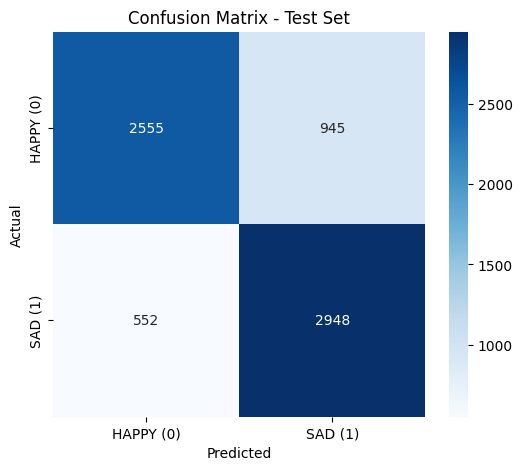


Final Test Accuracy: 78.61%


In [ ]:
def test_model(model, loader):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())

    return y_true, y_pred

# Run evaluation on Test Set
print("Evaluating on Test Set...")
true_labels, pred_labels = test_model(model, test_loader)

# 1. Print Classification Report
target_names = ['HAPPY (0)', 'SAD (1)']
report = classification_report(true_labels, pred_labels, target_names=target_names)
print("\n--- Classification Report ---\n")
print(report)

# 2. Plot Confusion Matrix
cm = confusion_matrix(true_labels, pred_labels)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Test Set')
plt.show()

# 3. Calculate Final Accuracy
accuracy = (cm[0,0] + cm[1,1]) / cm.sum() * 100
print(f"\nFinal Test Accuracy: {accuracy:.2f}%")

###  Results Analysis
The model was evaluated on the independent Test Set containing 7,000 samples (3,500 HAPPY, 3,500 SAD).

we reached a generalization with a final accuracy of 78.61%, which aligns closely with the validation accuracy observed during training.

1. Metric Breakdown

* Overall Accuracy (78.61%): The model correctly predicted the sentiment of nearly 79 out of every 100 comments. Given the noise inherent in social media text (slang, sarcasm, typos), this indicates a successful learning process without significant overfitting.

* Class-Specific Performance:

  * HAPPY (Label 0):

    * Precision (0.82): When the model predicts a comment is "HAPPY", it is correct 82% of the time. The model is highly reliable when it identifies positive sentiment.

    *  Recall (0.73): The model correctly identified 73% of all actual happy comments. It missed about 27% of them, misclassifying them as SAD.

  * SAD (Label 1):

    * Precision (0.76): When the model predicts a comment is "SAD", it is correct 76% of the time.

    * Recall (0.84): The model successfully detected 84% of all actual complaints/sad comments.

2. Confusion Matrix Interpretation

  Based on the recall and precision scores, the Confusion Matrix reveals a specific behavior bias:

* High Sensitivity to Negativity: The model has a higher Recall for the SAD class (0.84) compared to the HAPPY class (0.73).

* Implication: The network is "eager" to detect complaints. It is more likely to misclassify a slightly ambiguous Happy comment as Sad than to miss a Sad comment.

* Business Context: For a platform like SnappFood, this is actually a desirable trait. It is better to flag a happy comment as a complaint (False Positive) and have a human review it, than to ignore a genuine complaint (False Negative) thinking it was happy.

3. Conclusion

The balanced F1-Scores (0.77 vs 0.80) and the close proximity of Test Accuracy (78.61%) to Validation Accuracy (~78%) confirm that the techniques used—FastText Embeddings, Dropout, and Early Stopping—successfully prevented overfitting and produced a generalized model capable of handling real-world data.